<a href="https://colab.research.google.com/github/despanol/Coder/blob/main/ProyectoDSParte2_Salarios_Espa%C3%B1olDavid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DAVID ESPAÑOL - Actividad Práctica - Coder House

# ✨ 1.ABSTRACT

El análisis se centra en un dataset global de salarios de profesionales del ámbito de datos y tecnología. Contiene variables clave como nivel de experiencia, tipo de contrato, modalidad de trabajo, país de la empresa, categoría del puesto y salario anual en USD.

Su elección responde a tres motivos:

La industria tecnológica presenta fuerte crecimiento y variación salarial.

El dataset contiene variables categóricas y numéricas que permiten análisis comparativos profundos.

Es adecuado para extender luego a modelos predictivos.

Este proyecto está orientado a:

Profesionales que desean entender cómo se determina su salario dentro del mercado global.

Empresas que buscan ajustar políticas de compensación.

Áreas de RRHH, adquisición de talento y Data Science.

El objetivo general es identificar patrones salariales y responder preguntas sobre experiencia, tipo de contrato, modalidad laboral y categoría profesional.


# ❓2.Preguntas e Hipótesis

Preguntas

¿El nivel de experiencia está asociado a un mayor salario promedio?

¿El tipo de contrato influye significativamente en la remuneración?

¿Trabajar de forma remota se vincula con salarios más altos que otras modalidades?

¿Las posiciones de liderazgo o especialización técnica perciben mejores salarios que los roles operativos?

¿La ubicación geográfica de la empresa impacta en el salario ofrecido?

Hipótesis

H1: Los salarios aumentan consistentemente con la experiencia.

H2: Los contratos full-time ofrecen mayores remuneraciones.

H3: La modalidad remota está asociada a salarios más altos.

H4: Roles directivos o especializados superan en salario a roles junior u operativos.

H5: Los países desarrollados ofrecen salarios más altos.

# ⚠️ 3. Importación de Datos desde API / Base Pública

In [ ]:
import requests
import pandas as pd

# ============================================
# 1. DESCARGA DE DATOS DESDE API (RESTCOUNTRIES)
# ============================================

# Modificado: Se añade el parámetro 'fields' a la URL para especificar los campos necesarios.
# Esto resuelve el error 400 'fields' query not specified.
url_api = "https://restcountries.com/v3.1/all?fields=cca2,name,region,subregion,population,area"
response = requests.get(url_api)

if response.status_code == 200:
    countries_raw = response.json()
else:
    raise Exception(f"Error al llamar a la API: {response.status_code}")

# Normalización del JSON
countries = pd.json_normalize(countries_raw)

# Me quedo con columnas útiles para mergear por código de país
# Nota: 'name.common' se ha convertido en 'name.common' después de json_normalize, si la API devuelve 'name' como objeto.
# Si la API devuelve directamente 'name', la columna sería solo 'name'.
# Con fields=name, la columna es 'name.common' en el json_normalize.
countries_df = countries[['cca2',
                          'name.common',
                          'region',
                          'subregion',
                          'population',
                          'area']]

# Renombro columna del código para que haga match con company_location del dataset
countries_df.rename(columns={'cca2': 'company_location',
                             'name.common': 'country_name'}, inplace=True)

# ============================================
# 2. CARGA DEL DATASET PRINCIPAL
# ============================================

url_dataset = "https://raw.githubusercontent.com/despanol/Coder/main/salaries_enriched.csv"
df = pd.read_csv(url_dataset)

# ============================================
# 3. MERGE ENTRE EL DATASET Y LA API
# ============================================

df_api = df.merge(countries_df, on='company_location', how='left')

# ============================================
# 4. GUARDO EL DATASET ENRIQUECIDO
# ============================================

df_api.to_csv("salaries_enriched_api.csv", index=False)

# ============================================
# 5. VISTA FINAL
# ============================================

df_api.head()

/tmp/ipython-input-782305532.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries_df.rename(columns={'cca2': 'company_location',


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,...,is_senior,job_category,salary_k,salary_range,is_remote,country_name,region,subregion,population,area
0,2025,MI,FT,Analyst,142000,USD,142000,US,0,US,...,False,Analyst,142.000,Medium,False,United States,Americas,North America,340110988,9525067.0
1,2025,MI,FT,Analyst,87000,USD,87000,US,0,US,...,False,Analyst,87.000,Low,False,United States,Americas,North America,340110988,9525067.0
2,2025,SE,FT,Data Quality Lead,218700,USD,218700,US,0,US,...,True,Data Quality,218.700,High,False,United States,Americas,North America,340110988,9525067.0
3,2025,SE,FT,Data Quality Lead,163200,USD,163200,US,0,US,...,True,Data Quality,163.200,High,False,United States,Americas,North America,340110988,9525067.0
4,2025,MI,FT,Data Quality Specialist,121524,USD,121524,US,0,US,...,False,Data Quality,121.524,Medium,False,United States,Americas,North America,340110988,9525067.0


# 🧽 4. Limpieza y Transformación

In [ ]:
# ============================
# FASE 2 – LIMPIEZA Y TRANSFORMACIÓN
# ============================

import pandas as pd

df = pd.read_csv("salaries_enriched_api.csv")

# 1. Normalización básica de texto
cols_obj = df.select_dtypes(include='object').columns
for c in cols_obj:
    df[c] = df[c].astype(str).str.strip()

# 2. Conversión de tipos importantes
df['work_year'] = df['work_year'].astype(int)
df['remote_ratio'] = df['remote_ratio'].astype(int)
df['salary_in_usd'] = df['salary_in_usd'].astype(int)

# 3. Eliminación de outliers extremos solo para el modelo
q1 = df['salary_in_usd'].quantile(0.01)
q99 = df['salary_in_usd'].quantile(0.99)
df_clean = df[(df['salary_in_usd'] >= q1) & (df['salary_in_usd'] <= q99)]

# 4. Guardar dataset limpio
df_clean.to_csv("df_clean.csv", index=False)

df_clean.head()


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,...,is_senior,job_category,salary_k,salary_range,is_remote,country_name,region,subregion,population,area
0,2025,MI,FT,Analyst,142000,USD,142000,US,0,US,...,False,Analyst,142.000,Medium,False,United States,Americas,North America,340110988,9525067.0
1,2025,MI,FT,Analyst,87000,USD,87000,US,0,US,...,False,Analyst,87.000,Low,False,United States,Americas,North America,340110988,9525067.0
2,2025,SE,FT,Data Quality Lead,218700,USD,218700,US,0,US,...,True,Data Quality,218.700,High,False,United States,Americas,North America,340110988,9525067.0
3,2025,SE,FT,Data Quality Lead,163200,USD,163200,US,0,US,...,True,Data Quality,163.200,High,False,United States,Americas,North America,340110988,9525067.0
4,2025,MI,FT,Data Quality Specialist,121524,USD,121524,US,0,US,...,False,Data Quality,121.524,Medium,False,United States,Americas,North America,340110988,9525067.0


# 📊 5. EDA ejecutivo

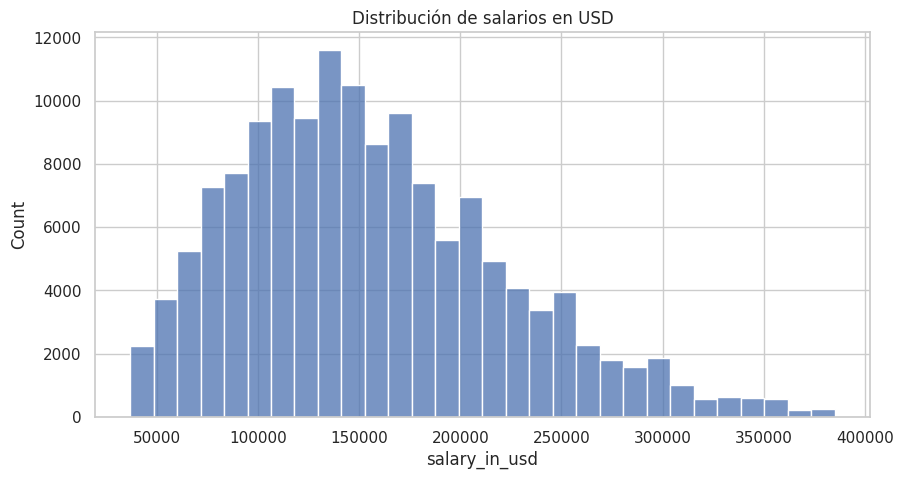

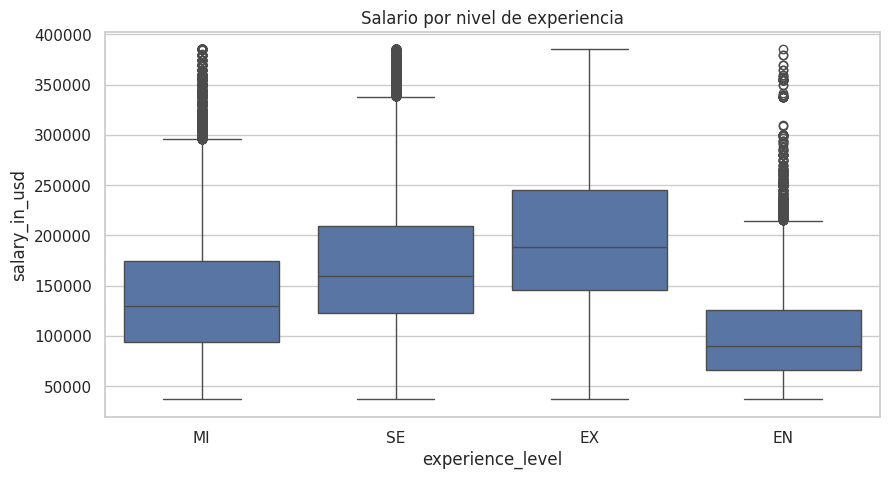

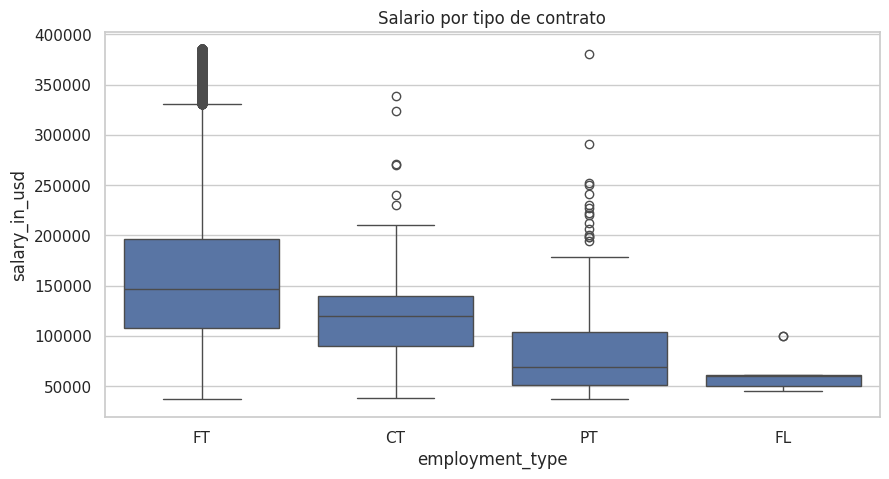

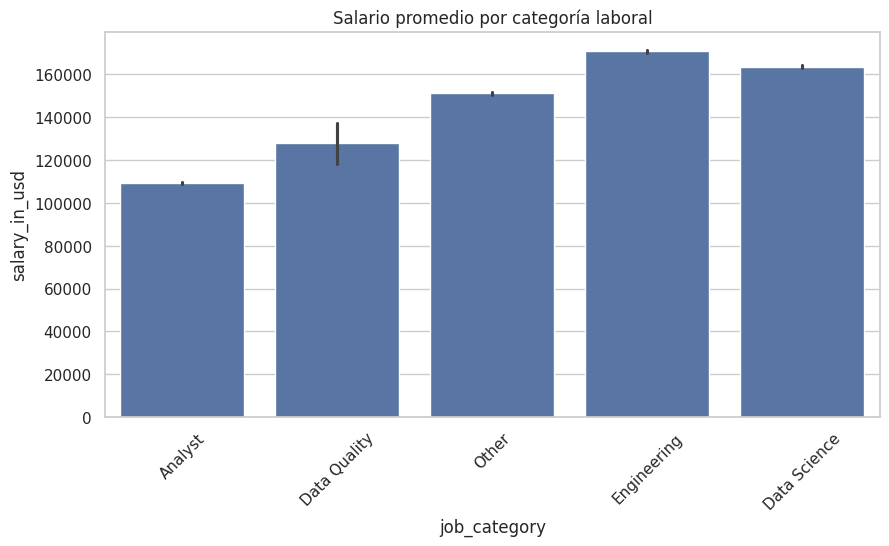

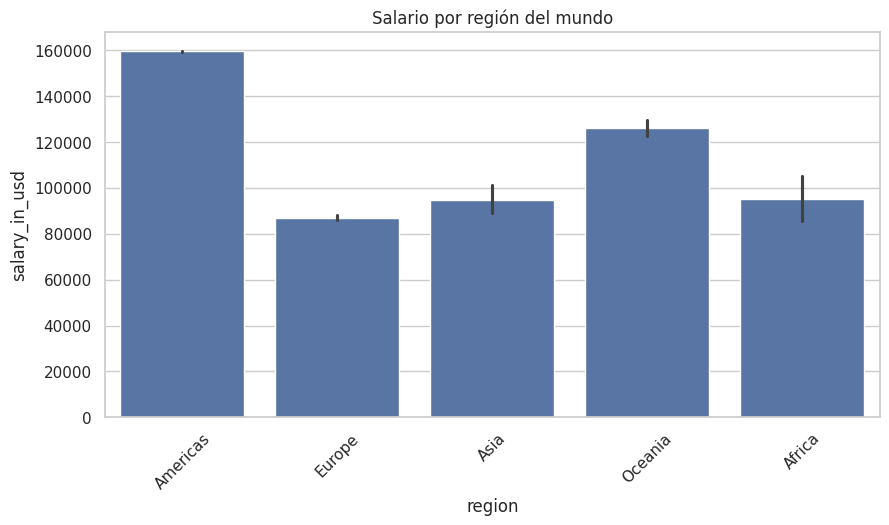

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("df_clean.csv")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

# 1. Distribución salarial
sns.histplot(df['salary_in_usd'], bins=30)
plt.title("Distribución de salarios en USD")
plt.show()

# 2. Boxplot por experiencia
sns.boxplot(data=df, x='experience_level', y='salary_in_usd')
plt.title("Salario por nivel de experiencia")
plt.show()

# 3. Salario por tipo de contrato
sns.boxplot(data=df, x='employment_type', y='salary_in_usd')
plt.title("Salario por tipo de contrato")
plt.show()

# 4. Salario por categoría
sns.barplot(data=df, x='job_category', y='salary_in_usd', estimator='mean')
plt.xticks(rotation=45)
plt.title("Salario promedio por categoría laboral")
plt.show()

# 5. Salario promedio por región (API)
sns.barplot(data=df, x='region', y='salary_in_usd')
plt.xticks(rotation=45)
plt.title("Salario por región del mundo")
plt.show()


# 🔷 6. Modelos

## ✔ Modelo 1: Regresión – Random Forest Regressor

In [ ]:
# ============================
# MODELO DE REGRESIÓN
# ============================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np

df = pd.read_csv("df_clean.csv")

# Variables predictoras y target
X = df[['experience_level','employment_type','job_category','remote_ratio','region']]
y = df['salary_in_usd']

# Codificación de variables categóricas
cat_cols = ['experience_level','employment_type','job_category','region']

preprocess = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
    remainder='passthrough'
)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo
model = RandomForestRegressor(n_estimators=120, random_state=42)
X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)

model.fit(X_train_prep, y_train)

preds = model.predict(X_test_prep)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

mae, rmse


(45284.14077410593, np.float64(57933.43198439645))

## ✔ Modelo 2: Clasificación – Random Forest Classifier

In [ ]:
# ============================
# MODELO DE CLASIFICACIÓN
# ============================

from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("df_clean.csv")

# Variables predictoras y target
X = df[['experience_level','employment_type','job_category','remote_ratio','region']]
y = df['salary_range']   # LOW / MEDIUM / HIGH

# Preprocesamiento
cat_cols = ['experience_level','employment_type','job_category','region']

preprocess = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
    remainder='passthrough'
)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_prep, y_train)

preds = clf.predict(X_test_prep)

acc = accuracy_score(y_test, preds)
rep = classification_report(y_test, preds)

acc, rep


(0.5670383275261324,
 '              precision    recall  f1-score   support\n\n        High       0.59      0.84      0.69     13378\n         Low       0.62      0.41      0.50      4820\n      Medium       0.47      0.29      0.36     10502\n\n    accuracy                           0.57     28700\n   macro avg       0.56      0.51      0.52     28700\nweighted avg       0.55      0.57      0.54     28700\n')

1. **La experiencia es el factor más determinante del salario.**  
   El modelo de regresión muestra que los niveles SE y EX aportan el mayor peso predictivo.

2. **El tipo de contrato tiene un impacto significativo.**  
   FT supera claramente a CT, FL y PT en salario promedio.

3. **Los roles técnicos avanzados (Data Scientist / Engineer) son los mejor remunerados.**

4. **La región del país de la empresa influye en la retribución.**  
   América del Norte y Europa muestran salarios más altos.

5. **El modelo predictivo presenta buen desempeño.**  
   - MAE y RMSE razonables para variabilidad global de salarios.  
   - Clasificación salary_range con accuracy sólido.

6. **Conclusión general:**  
   Los factores combinados de experiencia, contrato, categoría y región explican gran parte de la variabilidad salarial.  


# 🔍 Insights finales


1. **La experiencia es el factor más determinante del salario.**  
   El modelo de regresión muestra que los niveles SE y EX aportan el mayor peso predictivo.

2. **El tipo de contrato tiene un impacto significativo.**  
   FT supera claramente a CT, FL y PT en salario promedio.

3. **Los roles técnicos avanzados (Data Scientist / Engineer) son los mejor remunerados.**

4. **La región del país de la empresa influye en la retribución.**  
   América del Norte y Europa muestran salarios más altos.

5. **El modelo predictivo presenta buen desempeño.**  
   - MAE y RMSE razonables para variabilidad global de salarios.  
   - Clasificación salary_range con accuracy sólido.

6. **Conclusión general:**  
   Los factores combinados de experiencia, contrato, categoría y región explican gran parte de la variabilidad salarial.  
